/tmp/ipython-input-2382698635.py:49: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipython-input-2382698635.py:52: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(inner)


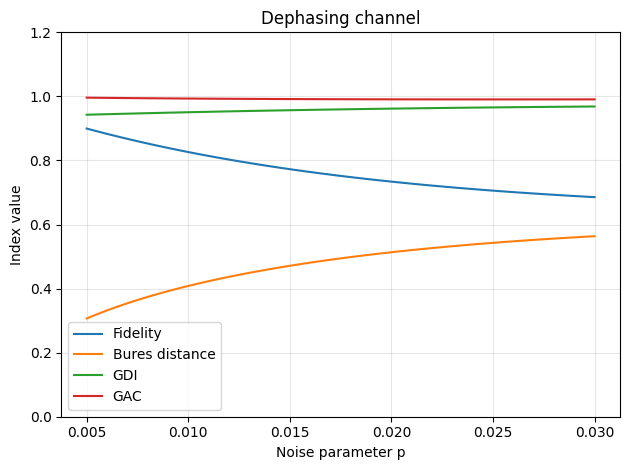

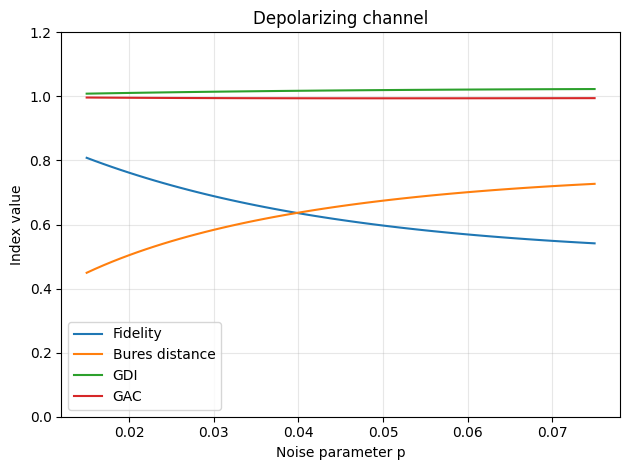

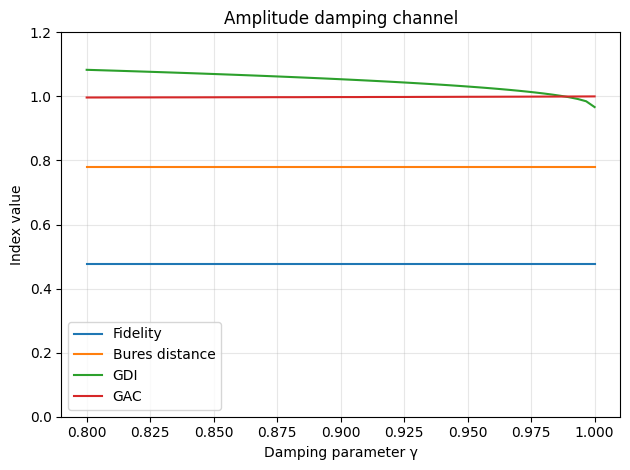

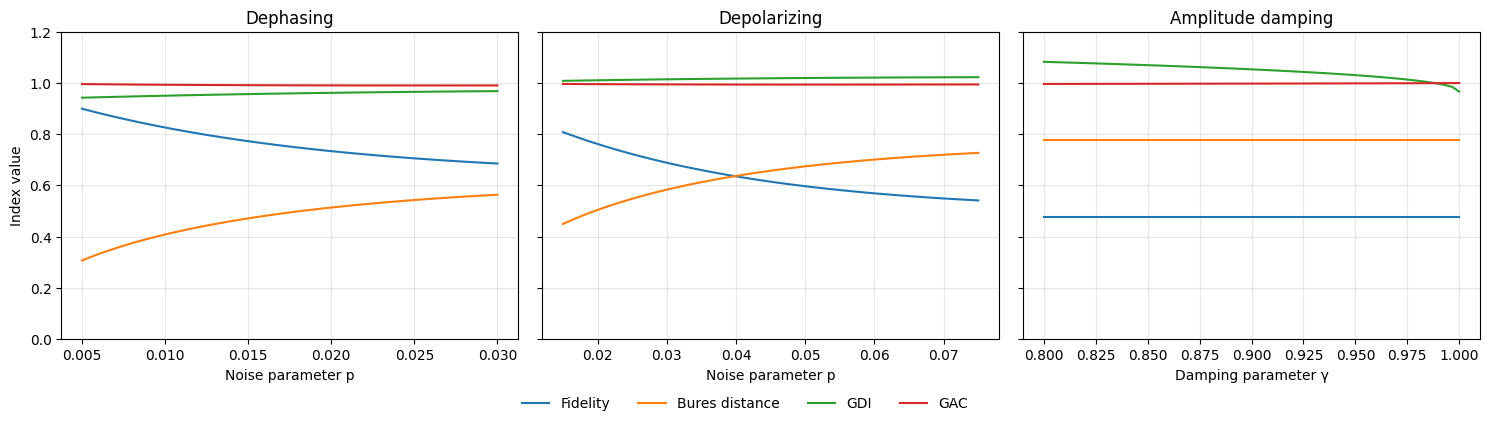

/tmp/ipython-input-2382698635.py:49: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipython-input-2382698635.py:52: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(inner)


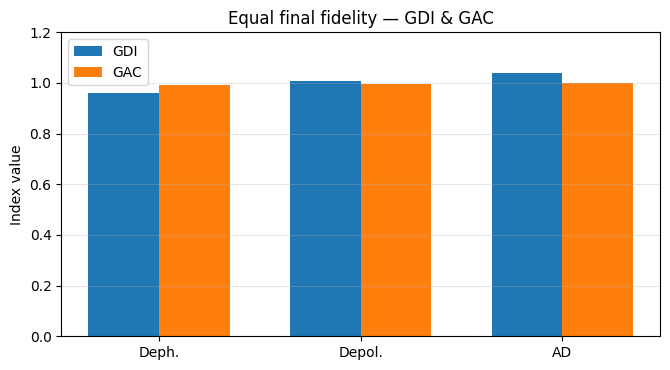

/tmp/ipython-input-2382698635.py:49: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipython-input-2382698635.py:52: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(inner)


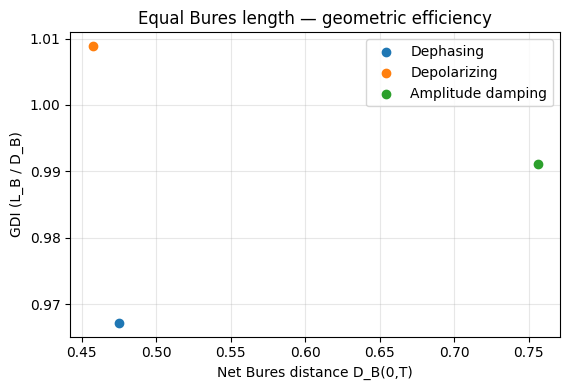

/tmp/ipython-input-2382698635.py:49: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  sr = sqrtm(rho)
/tmp/ipython-input-2382698635.py:52: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  root = sqrtm(inner)


Tab. 3 (protocol summary) stored in DataFrame `tab3`:
     protocol            channel     param         F        DB       GDI  \
0  FixedDepth          dephasing  0.017500  0.747299  0.493456  0.958592   
1  FixedDepth       depolarizing  0.045000  0.614572  0.657349  1.018692   
2  FixedDepth  amplitude_damping  0.900000  0.457904  0.804771  1.051931   
3     Equal-F          dephasing  0.016475  0.761247  0.483709  0.958639   
4     Equal-F       depolarizing  0.017446  0.784690  0.477855  1.009683   
5     Equal-F  amplitude_damping  0.946667  0.434823  0.823592  1.039058   
6    Equal-LB          dephasing  0.020625  0.761470  0.475289  0.967193   
7    Equal-LB       depolarizing  0.015659  0.801735  0.457391  1.008854   
8    Equal-LB  amplitude_damping  0.993333  0.498526  0.756046  0.991038   

        GAC        LB    max_aB  
0  0.991460  0.505109  0.053091  
1  0.994086  0.669636  0.074472  
2  0.997936  0.884550  0.408084  
3  0.991298  0.495840  0.051513  
4  0.996091  0.

In [1]:
import numpy as np
import pandas as pd
from numpy.random import default_rng
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
from io import BytesIO

# -----------------------------
# Configuration
# -----------------------------
N_POINTS     = 61       # number of points in each parameter sweep
DEPTH        = 32       # channel depth (repeated applications)
N_RANDOM     = 24       # number of random states (in addition to cardinal ones)
rng = default_rng(42)   # reproducible seed

# Experimental ranges (adjust if needed)
RANGE_DEPH = (0.005, 0.03)   # p for dephasing
RANGE_DEPO = (0.015, 0.075)  # p for depolarizing
RANGE_AD   = (0.80, 1.00)    # gamma for amplitude damping

# -----------------------------
# Linear algebra + Pauli matrices
# -----------------------------
I2 = np.eye(2, dtype=np.complex128)
X  = np.array([[0, 1],[1, 0]], dtype=np.complex128)
Y  = np.array([[0, -1j],[1j, 0]], dtype=np.complex128)
Z  = np.array([[1, 0],[0, -1]], dtype=np.complex128)

# -----------------------------
# State utilities + fidelity/Bures distance
# -----------------------------
def pure_to_rho(psi):
    """Return density matrix ρ = |ψ⟩⟨ψ| from a 2-component pure state."""
    psi = np.asarray(psi, dtype=np.complex128).reshape(2,1)
    psi = psi / np.linalg.norm(psi)
    return psi @ psi.conj().T

def haar_random_pure_qubit(n: int):
    """Generate n Haar-random pure qubit states (density matrices)."""
    states = []
    for _ in range(n):
        z = rng.normal(size=2) + 1j * rng.normal(size=2)
        psi = z / np.linalg.norm(z)
        states.append(pure_to_rho(psi))
    return states

def fidelity(rho, sigma):
    """Uhlmann fidelity F(ρ, σ)."""
    sr = sqrtm(rho)
    inner = sr @ sigma @ sr
    inner = (inner + inner.conj().T) / 2.0  # numerical symmetrization
    root = sqrtm(inner)
    val = np.real(np.trace(root))**2
    return float(np.clip(val, 0.0, 1.0))

def bures_distance(rho, sigma):
    """Bures distance D_B(ρ, σ)."""
    F = fidelity(rho, sigma)
    return float(np.sqrt(max(0.0, 2.0*(1.0 - np.sqrt(F)))))

# -----------------------------
# Channels (Kraus representations)
# -----------------------------
def apply_kraus(rho, Ks):
    """Apply a quantum channel in Kraus form to ρ."""
    out = np.zeros((2,2), dtype=np.complex128)
    for K in Ks:
        out += K @ rho @ K.conj().T
    out = (out + out.conj().T) / 2.0
    tr = np.real(np.trace(out))
    return out / tr if tr != 0 else I2/2

def dephasing_kraus(p):
    """Dephasing channel with parameter p."""
    return [np.sqrt(1-p)*I2, np.sqrt(p)*Z]

def depolarizing_kraus(p):
    """Depolarizing channel in Pauli form (valid for p in [0,1])."""
    a0 = np.sqrt(1 - 3*p/4); a = np.sqrt(p/4)
    return [a0*I2, a*X, a*Y, a*Z]

def amplitude_damping_kraus(g):
    """Amplitude damping channel with damping probability γ = g."""
    K0 = np.array([[1,0],[0,np.sqrt(1-g)]], dtype=np.complex128)
    K1 = np.array([[0,np.sqrt(g)],[0,0]], dtype=np.complex128)
    return [K0, K1]

# -----------------------------
# Trajectories and geometric metrics
# -----------------------------
def trajectory(rho0, kraus_fn, param, depth):
    """Generate trajectory {ρ_k} by iterating the channel at fixed parameter."""
    traj = [rho0]
    Ks = kraus_fn(param)
    rho = rho0
    for _ in range(depth):
        rho = apply_kraus(rho, Ks)
        traj.append(rho)
    return traj

def trajectory_length_bures(traj):
    """Total Bures length along the trajectory."""
    return sum(bures_distance(traj[i], traj[i+1]) for i in range(len(traj)-1))

def gdi(traj):
    """Geometric detour index GDI = L_B / D_B(ρ_0, ρ_T)."""
    LB = trajectory_length_bures(traj)
    DB = bures_distance(traj[0], traj[-1])
    return float(LB / max(DB, 1e-12))

def gac_mean(traj):
    """
    Mean local alignment (GAC) using a cosine-based surrogate:
    approximate the angle between local step and the net direction to the target
    via a Bures-space law of cosines.
    """
    T = traj[-1]; vals = []
    for i in range(len(traj)-1):
        A, B = traj[i], traj[i+1]
        dAB, dAT, dBT = bures_distance(A,B), bures_distance(A,T), bures_distance(B,T)
        denom = 2.0 * dAB * dAT
        if denom <= 1e-12:
            continue
        cos_th = (dAB**2 + dAT**2 - dBT**2) / denom
        vals.append(np.clip(np.real(cos_th), -1.0, 1.0))
    return float(np.mean(vals)) if vals else 1.0

def bures_speeds_and_accel(traj):
    """
    Local speeds and accelerations along a trajectory:
      v_k = D_B(ρ_k, ρ_{k+1})
      a_k ≈ |v_{k+1} − 2 v_k + v_{k-1}| (discrete second difference)
    Returns (v_list, a_list, max_accel).
    """
    v = [bures_distance(traj[i], traj[i+1]) for i in range(len(traj)-1)]
    a = []
    for i in range(1, len(v)-1):
        a.append(abs(v[i+1] - 2*v[i] + v[i-1]))
    max_a = max(a) if a else 0.0
    return v, a, max_a

# -----------------------------
# State sampling
# -----------------------------
def sample_states(n_random: int):
    """6 cardinal states + n_random Haar-random states."""
    CARDINAL = [
        pure_to_rho([1,0]), pure_to_rho([0,1]),
        pure_to_rho([1/np.sqrt(2),  1/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2), -1/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2),  1j/np.sqrt(2)]),
        pure_to_rho([1/np.sqrt(2), -1j/np.sqrt(2)]),
    ]
    return CARDINAL + haar_random_pure_qubit(n_random)

# -----------------------------
# Parameter sweep per channel (mean metrics)
# -----------------------------
def run_sweep_means(channel_name, kraus_fn, grid, depth, n_random):
    """
    For each parameter value in the grid, compute mean metrics
    across sampled input states: F, D_B, GDI, GAC.
    """
    rows = []
    states = sample_states(n_random)
    for param in grid:
        Fs, DBs, GDIs, GACs = [], [], [], []
        Ks = kraus_fn(float(param))
        for rho0 in states:
            traj = [rho0]
            rho = rho0
            for _ in range(depth):
                rho = apply_kraus(rho, Ks)
                traj.append(rho)
            Fs.append(fidelity(traj[0], traj[-1]))
            DBs.append(bures_distance(traj[0], traj[-1]))
            GDIs.append(gdi(traj))
            GACs.append(gac_mean(traj))
        rows.append({
            "channel": channel_name,
            "param": float(param),
            "F":   float(np.mean(Fs)),
            "DB":  float(np.mean(DBs)),
            "GDI": float(np.mean(GDIs)),
            "GAC": float(np.mean(GACs)),
        })
    return pd.DataFrame(rows)

# -----------------------------
# Grids and sweeps
# -----------------------------
grid_deph = np.linspace(*RANGE_DEPH, N_POINTS)
grid_depo = np.linspace(*RANGE_DEPO, N_POINTS)
grid_ad   = np.linspace(*RANGE_AD,   N_POINTS)

df_deph = run_sweep_means("dephasing",        dephasing_kraus,         grid_deph, DEPTH, N_RANDOM)
df_depo = run_sweep_means("depolarizing",     depolarizing_kraus,      grid_depo, DEPTH, N_RANDOM)
df_ad   = run_sweep_means("amplitude_damping",amplitude_damping_kraus, grid_ad,   DEPTH, N_RANDOM)

# -----------------------------
# Fig. 1 — Curves per channel (F, DB, GDI, GAC)
# -----------------------------
def plot_channel_curves(df, title, xlabel):
    """
    Plot channel diagnostics (F, D_B, GDI, GAC) vs parameter.
    Returns a BytesIO buffer containing the JPG image.
    """
    d = df.sort_values("param")
    fig, ax = plt.subplots()
    ax.plot(d["param"], d["F"],   label="Fidelity")
    ax.plot(d["param"], d["DB"],  label="Bures distance")
    ax.plot(d["param"], d["GDI"], label="GDI")
    ax.plot(d["param"], d["GAC"], label="GAC")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Index value")
    ax.set_title(title)
    ax.set_ylim(0, 1.2)
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

    # Save as in-memory JPG
    buf = BytesIO()
    fig.savefig(buf, dpi=300, format="jpg")
    buf.seek(0)
    return buf

buf_fig_deph = plot_channel_curves(df_deph, "Dephasing channel",        "Noise parameter p")
buf_fig_depo = plot_channel_curves(df_depo, "Depolarizing channel",     "Noise parameter p")
buf_fig_ad   = plot_channel_curves(df_ad,   "Amplitude damping channel","Damping parameter γ")

# Panel with 3 subplots (one per channel)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

d = df_deph.sort_values("param")
axes[0].plot(d["param"], d["F"],   label="Fidelity")
axes[0].plot(d["param"], d["DB"],  label="Bures distance")
axes[0].plot(d["param"], d["GDI"], label="GDI")
axes[0].plot(d["param"], d["GAC"], label="GAC")
axes[0].set_title("Dephasing")
axes[0].set_xlabel("Noise parameter p")
axes[0].set_ylabel("Index value")
axes[0].set_ylim(0, 1.2)
axes[0].grid(alpha=0.3)

d = df_depo.sort_values("param")
axes[1].plot(d["param"], d["F"])
axes[1].plot(d["param"], d["DB"])
axes[1].plot(d["param"], d["GDI"])
axes[1].plot(d["param"], d["GAC"])
axes[1].set_title("Depolarizing")
axes[1].set_xlabel("Noise parameter p")
axes[1].set_ylim(0, 1.2)
axes[1].grid(alpha=0.3)

d = df_ad.sort_values("param")
axes[2].plot(d["param"], d["F"])
axes[2].plot(d["param"], d["DB"])
axes[2].plot(d["param"], d["GDI"])
axes[2].plot(d["param"], d["GAC"])
axes[2].set_title("Amplitude damping")
axes[2].set_xlabel("Damping parameter γ")
axes[2].set_ylim(0, 1.2)
axes[2].grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout()
plt.subplots_adjust(bottom=0.18)

# Show panel
plt.show()

# Save panel as in-memory JPG
buf_panel_channels = BytesIO()
fig.savefig(buf_panel_channels, dpi=300, format="jpg")
buf_panel_channels.seek(0)

# -----------------------------
# Average metrics per parameter (for protocols)
# -----------------------------
def mean_metrics_for_param(kraus_fn, param, depth, n_random):
    """
    For a fixed parameter and depth, compute mean metrics across sampled states:
      F, D_B, GDI, GAC, L_B, max a_B.
    """
    states = sample_states(n_random)
    Fs, DBs, GDIs, GACs, LBs, maxAs = [], [], [], [], [], []
    Ks = kraus_fn(float(param))
    for rho0 in states:
        traj = [rho0]
        rho = rho0
        for _ in range(depth):
            rho = apply_kraus(rho, Ks)
            traj.append(rho)
        Fs.append(fidelity(traj[0], traj[-1]))
        DBs.append(bures_distance(traj[0], traj[-1]))
        GDIs.append(gdi(traj))
        GACs.append(gac_mean(traj))
        LBs.append(trajectory_length_bures(traj))
        _, _, max_a = bures_speeds_and_accel(traj)
        maxAs.append(max_a)
    return {
        "F":   float(np.mean(Fs)),
        "DB":  float(np.mean(DBs)),
        "GDI": float(np.mean(GDIs)),
        "GAC": float(np.mean(GACs)),
        "LB":  float(np.mean(LBs)),
        "max_aB": float(np.mean(maxAs))
    }

# -----------------------------
# Robust helpers to find target parameters
# -----------------------------
def find_param_for_target(kraus_fn, depth, n_random,
                          target, lo, hi,
                          metric_key="F", tol=1e-4, maxit=60):
    """
    1D bisection assuming monotonicity of the given metric in [lo, hi].
    Raises ValueError if the target is not bracketed in [lo, hi].
    """
    def mval(x):
        return mean_metrics_for_param(kraus_fn, x, depth, n_random)[metric_key]

    f_lo, f_hi = mval(lo), mval(hi)
    if not ((f_lo >= target >= f_hi) or (f_lo <= target <= f_hi)):
        raise ValueError(
            f"Target {target:.5f} not bracketed in [{lo:.5f},{hi:.5f}] "
            f"for metric {metric_key}: f(lo)={f_lo:.5f}, f(hi)={f_hi:.5f}"
        )

    a, b = lo, hi
    for _ in range(maxit):
        mid = 0.5*(a+b)
        f_mid = mval(mid)
        if abs(f_mid - target) < tol:
            return mid, f_mid
        # Determine monotonicity from the endpoints
        if (f_lo < f_hi):  # increasing
            if f_mid < target:
                a = mid
            else:
                b = mid
        else:              # decreasing
            if f_mid > target:
                a = mid
            else:
                b = mid
    return mid, f_mid

def find_param_or_nearest(kraus_fn, depth, n_random,
                          target, grid,
                          metric_key="F"):
    """
    Try bisection to match the target metric; if it fails,
    fall back to a discrete search over the grid, picking
    the closest metric value.
    """
    lo, hi = float(grid[0]), float(grid[-1])
    try:
        p_star, val = find_param_for_target(
            kraus_fn, depth, n_random,
            target, lo, hi,
            metric_key=metric_key
        )
        return float(p_star), float(val)
    except Exception:
        rows = []
        for p in grid:
            val = mean_metrics_for_param(kraus_fn, float(p), depth, n_random)[metric_key]
            rows.append((float(p), float(val)))
        p_star, val_star = min(rows, key=lambda t: abs(t[1]-target))
        return p_star, val_star

# -----------------------------
# Protocol P2: Equal final fidelity — bar plot (GDI & GAC)
# -----------------------------
ref_p = float(np.median(grid_deph))
ref_metrics = mean_metrics_for_param(dephasing_kraus, ref_p, DEPTH, N_RANDOM)
F_star = ref_metrics["F"]

p_deph_P2, _ = find_param_or_nearest(dephasing_kraus,        DEPTH, N_RANDOM, F_star, grid_deph, metric_key="F")
p_depo_P2, _ = find_param_or_nearest(depolarizing_kraus,     DEPTH, N_RANDOM, F_star, grid_depo, metric_key="F")
g_ad_P2,   _ = find_param_or_nearest(amplitude_damping_kraus, DEPTH, N_RANDOM, F_star, grid_ad,   metric_key="F")

met_deph_P2 = mean_metrics_for_param(dephasing_kraus,        p_deph_P2, DEPTH, N_RANDOM)
met_depo_P2 = mean_metrics_for_param(depolarizing_kraus,     p_depo_P2, DEPTH, N_RANDOM)
met_ad_P2   = mean_metrics_for_param(amplitude_damping_kraus, g_ad_P2,   DEPTH, N_RANDOM)

df_P2 = pd.DataFrame([
    {"protocol":"Equal-F", "channel":"dephasing",         "param":p_deph_P2, **met_deph_P2},
    {"protocol":"Equal-F", "channel":"depolarizing",      "param":p_depo_P2, **met_depo_P2},
    {"protocol":"Equal-F", "channel":"amplitude_damping", "param":g_ad_P2,   **met_ad_P2},
])

# Fig: bars for GDI and GAC (Equal-F)
fig, ax = plt.subplots(figsize=(6.8,3.8))
cats = ["dephasing","depolarizing","amplitude_damping"]
GDI_vals = [met_deph_P2["GDI"], met_depo_P2["GDI"], met_ad_P2["GDI"]]
GAC_vals = [met_deph_P2["GAC"], met_depo_P2["GAC"], met_ad_P2["GAC"]]
x = np.arange(len(cats)); w = 0.35
ax.bar(x - w/2, GDI_vals, width=w, label="GDI")
ax.bar(x + w/2, GAC_vals, width=w, label="GAC")
ax.set_xticks(x)
ax.set_xticklabels(["Deph.", "Depol.", "AD"])
ax.set_ylabel("Index value")
ax.set_title("Equal final fidelity — GDI & GAC")
ax.set_ylim(0, 1.2)
ax.grid(alpha=0.3, axis='y')
ax.legend()
fig.tight_layout()

plt.show()

buf_equalF_GDI_GAC = BytesIO()
fig.savefig(buf_equalF_GDI_GAC, dpi=300, format="jpg")
buf_equalF_GDI_GAC.seek(0)

# -----------------------------
# Protocol P3: Equal Bures length — geometric efficiency
# -----------------------------
LB_star = ref_metrics["LB"]

p_deph_P3, _ = find_param_or_nearest(dephasing_kraus,        DEPTH, N_RANDOM, LB_star, grid_deph, metric_key="LB")
p_depo_P3, _ = find_param_or_nearest(depolarizing_kraus,     DEPTH, N_RANDOM, LB_star, grid_depo, metric_key="LB")
g_ad_P3,   _ = find_param_or_nearest(amplitude_damping_kraus, DEPTH, N_RANDOM, LB_star, grid_ad,   metric_key="LB")

met_deph_P3 = mean_metrics_for_param(dephasing_kraus,        p_deph_P3, DEPTH, N_RANDOM)
met_depo_P3 = mean_metrics_for_param(depolarizing_kraus,     p_depo_P3, DEPTH, N_RANDOM)
met_ad_P3   = mean_metrics_for_param(amplitude_damping_kraus, g_ad_P3,   DEPTH, N_RANDOM)

df_P3 = pd.DataFrame([
    {"protocol":"Equal-LB", "channel":"dephasing",         "param":p_deph_P3, **met_deph_P3},
    {"protocol":"Equal-LB", "channel":"depolarizing",      "param":p_depo_P3, **met_depo_P3},
    {"protocol":"Equal-LB", "channel":"amplitude_damping", "param":g_ad_P3,   **met_ad_P3},
])

# Fig: geometric efficiency (GDI vs DB)
fig, ax = plt.subplots(figsize=(5.8,4.0))
ax.scatter(met_deph_P3["DB"], met_deph_P3["GDI"], label="Dephasing")
ax.scatter(met_depo_P3["DB"], met_depo_P3["GDI"], label="Depolarizing")
ax.scatter(met_ad_P3["DB"],   met_ad_P3["GDI"],   label="Amplitude damping")
ax.set_xlabel("Net Bures distance D_B(0,T)")
ax.set_ylabel("GDI (L_B / D_B)")
ax.set_title("Equal Bures length — geometric efficiency")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

plt.show()

buf_equalLB_efficiency = BytesIO()
fig.savefig(buf_equalLB_efficiency, dpi=300, format="jpg")
buf_equalLB_efficiency.seek(0)

# -----------------------------
# Protocol P1: Fixed depth (representative parameter per channel)
# -----------------------------
p_deph_P1 = float(np.median(grid_deph))
p_depo_P1 = float(np.median(grid_depo))
g_ad_P1   = float(np.median(grid_ad))

met_deph_P1 = mean_metrics_for_param(dephasing_kraus,        p_deph_P1, DEPTH, N_RANDOM)
met_depo_P1 = mean_metrics_for_param(depolarizing_kraus,     p_depo_P1, DEPTH, N_RANDOM)
met_ad_P1   = mean_metrics_for_param(amplitude_damping_kraus, g_ad_P1,   DEPTH, N_RANDOM)

df_P1 = pd.DataFrame([
    {"protocol":"FixedDepth", "channel":"dephasing",         "param":p_deph_P1, **met_deph_P1},
    {"protocol":"FixedDepth", "channel":"depolarizing",      "param":p_depo_P1, **met_depo_P1},
    {"protocol":"FixedDepth", "channel":"amplitude_damping", "param":g_ad_P1,   **met_ad_P1},
])

# -----------------------------
# Tab. 3 — consolidated protocol summary
# -----------------------------
tab3 = pd.concat([df_P1, df_P2, df_P3], ignore_index=True)

print("Tab. 3 (protocol summary) stored in DataFrame `tab3`:")
print(tab3)